In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [26]:
df_pre = pd.read_csv("data/answers1.csv")

df_pre = df_pre.drop(columns=df_pre.columns[:18])
df_pre = df_pre.drop(["Q4_4"], axis=1)
df_pre = df_pre[(df_pre['Q1'] != 'TEST' ) & (df_pre['Q1'].notna())]

In [27]:
df_post = pd.read_csv("data/answers2.csv")

df_post = df_post.drop(columns=df_post.columns[:17])
df_post = df_post.drop(["Q4_4"], axis=1)

df_post.head()

,Q1,Q2_1,Q2_2,Q2_3,Q3,Q4_1,Q4_2,Q4_3,Q4_5,Q4_6,...,Q7_6,Q8,Q9,Q10,Extra questions,Q11,Q12,Q13,Q14,Q15
0,What is your ID number? (The person who sent y...,What is your view on Data Privacy? - I feel kn...,What is your view on Data Privacy? - I want to...,What is your view on Data Privacy? - I think D...,What topics do you feel knowledgeable about,How much do you agree with the following state...,How much do you agree with the following state...,How much do you agree with the following state...,How much do you agree with the following state...,How much do you agree with the following state...,...,Which games were the most useful to you? - Bui...,(Optional) Were there any topics that you thou...,(Optional) Are there any games that stood out ...,(Optional) Are there any games that stood out ...,Are you willing to answer some extra questions...,(Optional) What did you think about the divers...,(Optional) What did you think about the diffic...,(Optional) What did you think about the length...,(Optional) Are there any other thoughts you wa...,(Optional) Would you be willing to share your ...
1,"{""ImportId"":""QID1_TEXT""}","{""ImportId"":""QID3_1""}","{""ImportId"":""QID3_2""}","{""ImportId"":""QID3_3""}","{""ImportId"":""QID15""}","{""ImportId"":""QID9_1""}","{""ImportId"":""QID9_2""}","{""ImportId"":""QID9_3""}","{""ImportId"":""QID9_6""}","{""ImportId"":""QID9_7""}",...,"{""ImportId"":""QID5_6""}","{""ImportId"":""QID24_TEXT""}","{""ImportId"":""QID7_TEXT""}","{""ImportId"":""QID8_TEXT""}","{""ImportId"":""QID22""}","{""ImportId"":""QID10_TEXT""}","{""ImportId"":""QID11_TEXT""}","{""ImportId"":""QID12_TEXT""}","{""ImportId"":""QID13_TEXT""}","{""ImportId"":""QID16_TEXT""}"
2,100,Strongly agree,Neither agree nor disagree,Strongly agree,"Password strength,Building and using a passphr...",Strongly agree,Somewhat agree,Strongly agree,Somewhat agree,Strongly agree,...,NaN,NaN,NaN,NaN,Yes,They were the right amount of different from e...,I found the medium and hard level in build a p...,In build a password the game got long because ...,The website looked very cool and the design of...,NaN
3,400,Somewhat agree,Strongly agree,Strongly agree,"Password strength,Building and using a passphr...",Strongly agree,Strongly agree,Neither agree nor disagree,Somewhat agree,Neither agree nor disagree,...,NaN,NaN,NaN,NaN,Yes,NaN,Too easy,Length is not important,NaN,NaN
4,403,Somewhat agree,Strongly agree,Strongly agree,"Password strength,Building and using a passphr...",Strongly agree,Strongly agree,Somewhat agree,Somewhat agree,Somewhat agree,...,NaN,Cookies (thought that i\r\nI can click x and i...,I liked th3 GDPR quiz and the cookies game bec...,Password constructing was a bit boring and ted...,Yes,"Two password games were a bit too much alike, ...",Extremely easy but still engaging to some exte...,"Perfect length, not long at all. Quite short a...",NaN,NaN


In [28]:
agreement_map = {
    "Strongly disagree": -2,
    "Somewhat disagree": -1,
    "Neither agree nor disagree": 0,
    "Somewhat agree": 1,
    "Strongly agree": 2,
}

In [46]:
color_pre ="#5bc0de"
color_post = "#2080a0"

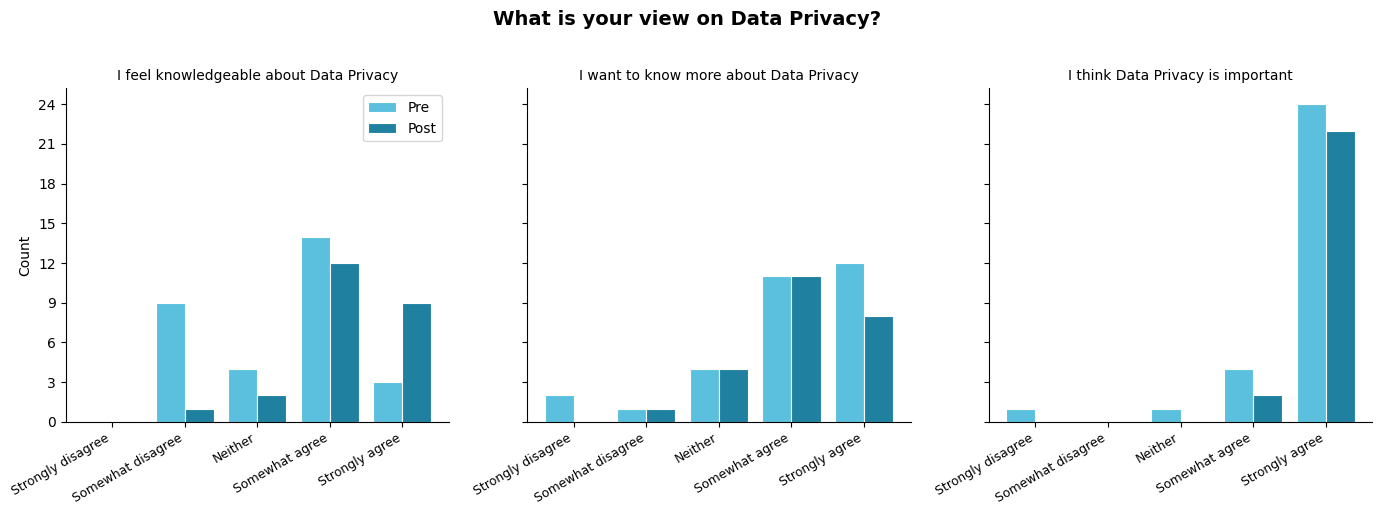

I feel knowledgeable about Data Privacy: 
  median pre=0.0, post=1.0
  W=11.500, p=0.00038 *

I want to know more about Data Privacy: 
  median pre=1.0, post=1.0
  W=104.000, p=0.50000 

I think Data Privacy is important: 
  median pre=2.0, post=2.0
  W=0.000, p=0.04172 *



In [84]:
# Q2 is repeated 
Q2s = []
Q2n_pre = []
Q2n_post = []

# histogram comparison (can't see pairing)
#  
for i in range(3):
    title = df_pre[f"Q2_{i+1}"][0]
    Q2s.append(title.replace("What is your view on Data Privacy? - ", ""))
    Q2n_post.append(df_post[f"Q2_{i+1}"][2:].map(agreement_map).reset_index(drop=True))
    Q2n_pre.append(df_pre[f"Q2_{i+1}"][2:].map(agreement_map).reset_index(drop=True))

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(14, 5))
fig.suptitle("What is your view on Data Privacy?", fontsize=14, fontweight="bold", y=1.02)

labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
bins = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

for i, (pre, post) in enumerate(zip(Q2n_pre, Q2n_post)):
    width = 0.4
    bin_centers = [-2, -1, 0, 1, 2]
    pre_counts = [((pre == v).sum()) for v in bin_centers]
    post_counts = [((post == v).sum()) for v in bin_centers]

    bars_pre = ax[i].bar([x - width/2 for x in bin_centers], pre_counts, width=width, color=color_pre, edgecolor="white", linewidth=0.8, label="Pre")
    bars_post = ax[i].bar([x + width/2 for x in bin_centers], post_counts, width=width, color=color_post, edgecolor="white", linewidth=0.8, label="Post")

    ax[i].set_xticks(bin_centers, labels, rotation=30, ha="right", fontsize=9)
    ax[i].set_title(Q2s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
ax[0].legend()
plt.tight_layout()
plt.show()

# > statistical comparison use wilcoxon (non normal and discrete ranks)
for i in range(3):
    # Match pre and post by ID ("Q1")
    pre_col = df_pre[["Q1", f"Q2_{i+1}"]].iloc[2:].rename(columns={f"Q2_{i+1}": "pre"})
    post_col = df_post[["Q1", f"Q2_{i+1}"]].iloc[2:].rename(columns={f"Q2_{i+1}": "post"})
    
    paired = pre_col.merge(post_col, on="Q1").dropna()
    paired["pre"] = paired["pre"].map(agreement_map)
    paired["post"] = paired["post"].map(agreement_map)
    paired = paired.dropna()

    # zpratt to only look at direction, not magnitude
    stat, p = stats.wilcoxon(
        paired["pre"], 
        paired["post"], 
        alternative="less", 
        zero_method="pratt"
    )
    
    print(f"{Q2s[i]}: ")
    print(f"  median pre={paired['pre'].median():.1f}, post={paired['post'].median():.1f}")
    print(f"  W={stat:.3f}, p={p:.5f} {'*' if p < 0.05 else ''}\n")

In [47]:
label_map = {
    "None of these": "None",
    "Rejecting tracking cookies": "Cookies",
    "Password strength": "Password Strength",
    "Building and using a passphrase": "Passphrases",
    "Spotting phishing emails": "Phishing Emails",
    "Basic information about the GDPR (General Data Protection Regulation)": "GDPR"
}

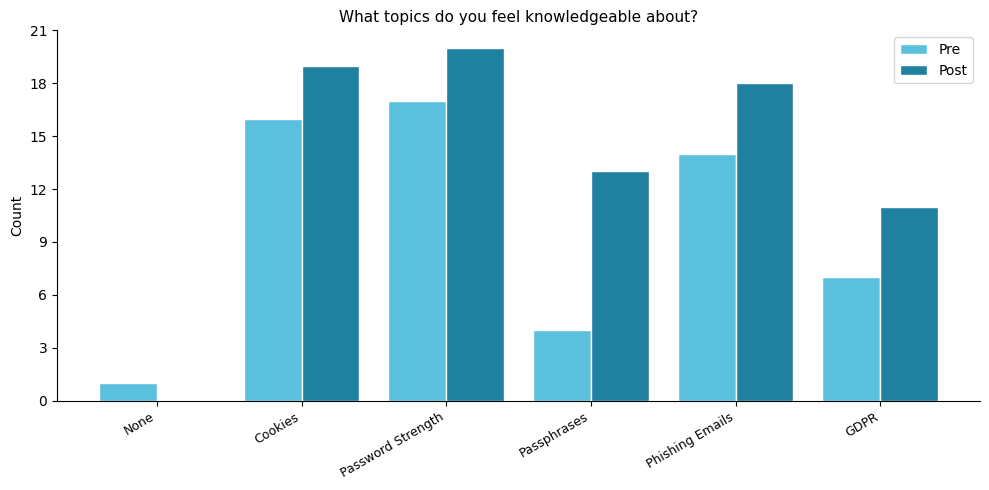

In [81]:
# Q3 is repeated 

# Data
Q3_pre = df_pre["Q3"][2:].dropna()
Q3_post = df_post["Q3"][2:].dropna()

# Build per-participant binary matrix
def to_binary(series, id_series):
    rows = []
    for id_, val in zip(id_series, series):
        selected = [v.strip() for v in val.split(",")]
        row = {"Q1": id_}
        for full, short in label_map.items():
            row[short] = int(full in selected)
        rows.append(row)
    return pd.DataFrame(rows)

pre_binary = to_binary(df_pre["Q3"].iloc[2:].dropna(), df_pre["Q1"].iloc[2:])
post_binary = to_binary(df_post["Q3"].iloc[2:].dropna(), df_post["Q1"].iloc[2:])

paired = pre_binary.merge(post_binary, on="Q1", suffixes=("_pre", "_post"))

# Plot
short_labels = list(label_map.values())
pre_counts = [paired[f"{l}_pre"].sum() for l in short_labels]
post_counts = [paired[f"{l}_post"].sum() for l in short_labels]

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.4
x = range(len(short_labels))
ax.bar([i - width/2 for i in x], pre_counts, width=width, color=color_pre, edgecolor="white", label="Pre")
ax.bar([i + width/2 for i in x], post_counts, width=width, color=color_post, edgecolor="white", label="Post")
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Count")
ax.set_title(df_pre["Q3"][0], fontsize=11, wrap=True)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()

# I think too few for statistical tests

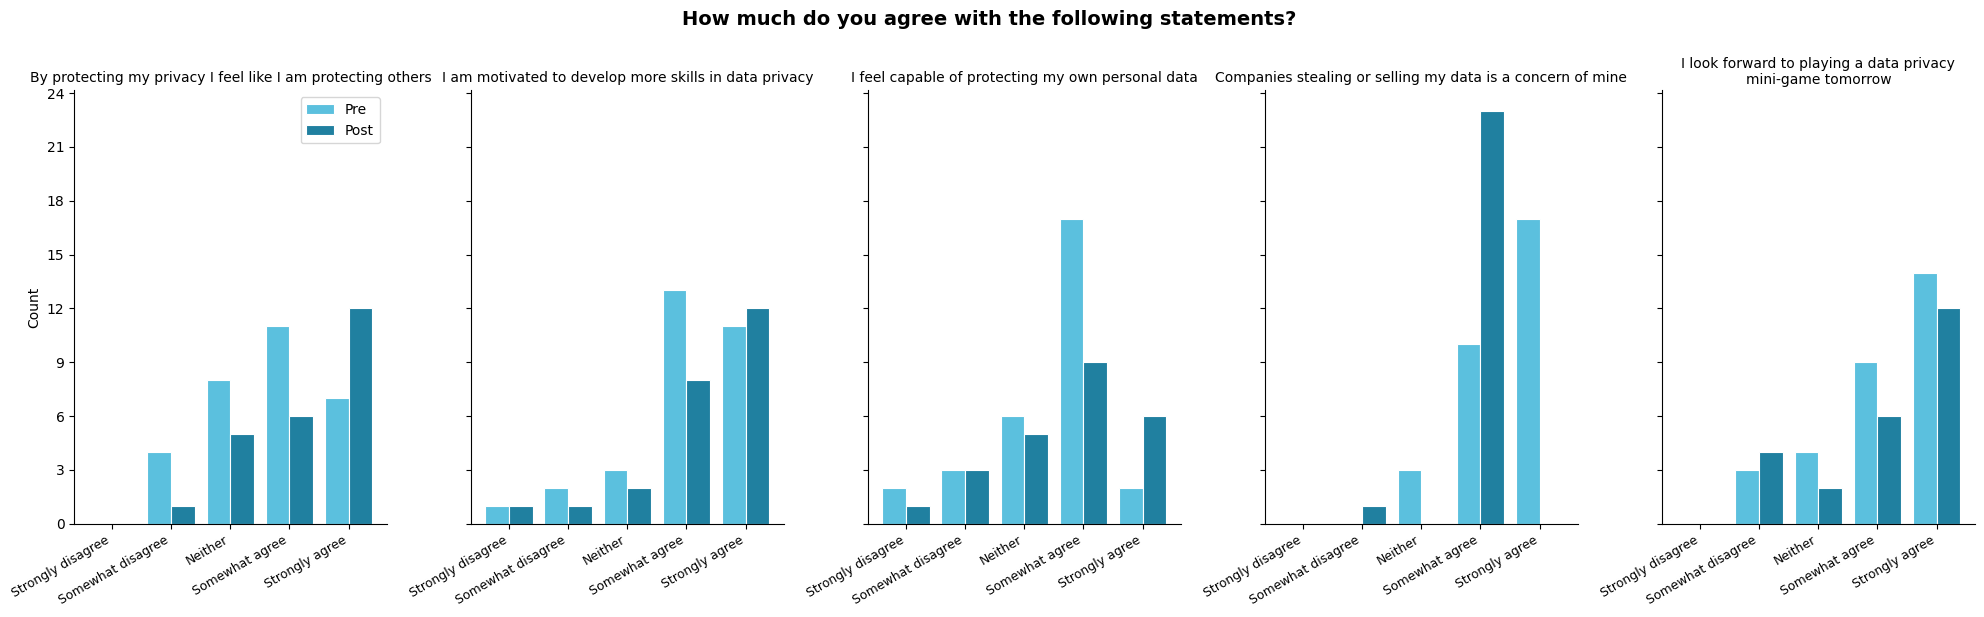

Wilcoxon signed-rank test (pre vs post):
By protecting my privacy I feel like I am protecting others
    median pre=1.0, post=1.0
    W=25.500, p=0.020 *

I am motivated to develop more skills in data privacy
    median pre=1.0, post=1.0
    W=27.500, p=0.500 

I feel capable of protecting my own personal data
    median pre=1.0, post=1.0
    W=37.000, p=0.262 

I look forward to playing a data privacy mini-game tomorrow
    median pre=2.0, post=1.0
    W=105.000, p=0.998 



In [64]:
# Q4
Q4s = []
Q4n_pre = []
Q4n_post = []

for i in range(6):
    col = f"Q4_{i+1}"
    if col not in df_pre.columns or col not in df_post.columns:
        continue
    Q4s.append(df_pre[col][0].replace("How much do you agree with the following statements? - ", ""))
    Q4n_pre.append(df_pre[col][2:].map(agreement_map))
    Q4n_post.append(df_post[col][2:].map(agreement_map))

n = len(Q4s)
fig, ax = plt.subplots(1, n, sharey=True, figsize=(4*n, 6))
ax = ax.flatten()
fig.suptitle("How much do you agree with the following statements?", fontsize=14, fontweight="bold", y=1.02)
bin_centers = [-2, -1, 0, 1, 2]
labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
width = 0.4

for i, (pre, post) in enumerate(zip(Q4n_pre, Q4n_post)):
    pre_counts = [(pre == v).sum() for v in bin_centers]
    post_counts = [(post == v).sum() for v in bin_centers]
    ax[i].bar([x - width/2 for x in bin_centers], pre_counts, width=width, color=color_pre, edgecolor="white", linewidth=0.8, label="Pre")
    ax[i].bar([x + width/2 for x in bin_centers], post_counts, width=width, color=color_post, edgecolor="white", linewidth=0.8, label="Post")
    ax[i].set_xticks(bin_centers, labels, rotation=30, ha="right", fontsize=9)
    ax[i].set_title(Q4s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
ax[0].legend()
plt.tight_layout()
plt.show()

from scipy import stats

print("Wilcoxon signed-rank test (pre vs post):")
for i in range(len(Q4s)):
    col = f"Q4_{i+1}"
    if col not in df_pre.columns or col not in df_post.columns:
        continue
    pre_col = df_pre[["Q1", col]].iloc[2:].rename(columns={f"Q4_{i+1}": "pre"})
    post_col = df_post[["Q1", col]].iloc[2:].rename(columns={f"Q4_{i+1}": "post"})
    paired = pre_col.merge(post_col, on="Q1").dropna()
    paired["pre"] = paired["pre"].map(agreement_map)
    paired["post"] = paired["post"].map(agreement_map)
    paired = paired.dropna()

    stat, p = stats.wilcoxon(paired["pre"], paired["post"], alternative="less")
    print(f"{Q4s[i]}")
    print(f"    median pre={paired['pre'].median():.1f}, post={paired['post'].median():.1f}")
    print(f"    W={stat:.3f}, p={p:.3f} {'*' if p < 0.05 else ''}\n")

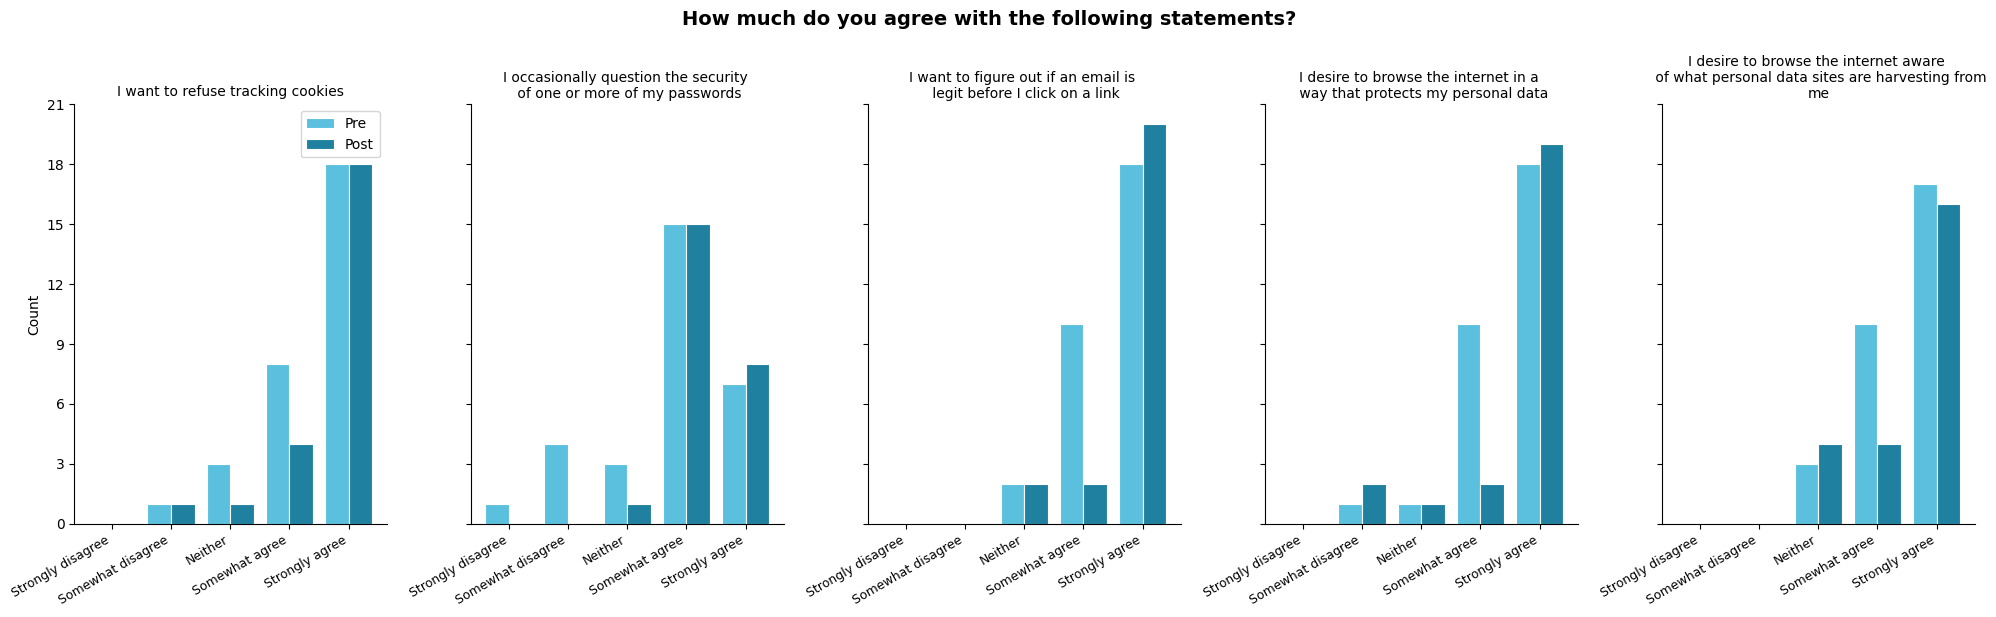

Wilcoxon signed-rank test (pre vs post):
I want to refuse tracking cookies
    median pre=2.0, post=2.0
    W=14.500, p=0.304 

I occasionally question the security 
 of one or more of my passwords
    median pre=1.0, post=1.0
    W=7.000, p=0.029 *

I want to figure out if an email is 
 legit before I click on a link
    median pre=2.0, post=2.0
    W=15.000, p=0.083 

I desire to browse the internet in a 
 way that protects my personal data
    median pre=2.0, post=2.0
    W=9.000, p=0.369 

I desire to browse the internet aware 
 of what personal data sites are harvesting from me
    median pre=2.0, post=2.0
    W=20.500, p=0.640 



In [66]:
# Q5

Q5s = []
Q5n_pre = []
Q5n_post = []

subtitle = [
    "I want to refuse tracking cookies",
    "I occasionally question the security \n of one or more of my passwords",
    "I want to figure out if an email is \n legit before I click on a link",
    "I desire to browse the internet in a \n way that protects my personal data",
    "I desire to browse the internet aware \n of what personal data sites are harvesting from me",
]

for i in range(5):
    col = f"Q5_{i+1}"
    Q5s.append(subtitle[i])
    Q5n_pre.append(df_pre[col][2:].map(agreement_map))
    Q5n_post.append(df_post[col][2:].map(agreement_map))

n = len(Q5s)
fig, ax = plt.subplots(1, n, sharey=True, figsize=(4*n, 6))
ax = ax.flatten()
fig.suptitle("How much do you agree with the following statements?", fontsize=14, fontweight="bold", y=1.02)
bin_centers = [-2, -1, 0, 1, 2]
labels = ["Strongly disagree", "Somewhat disagree", "Neither", "Somewhat agree", "Strongly agree"]
width = 0.4

for i, (pre, post) in enumerate(zip(Q5n_pre, Q5n_post)):
    pre_counts = [(pre == v).sum() for v in bin_centers]
    post_counts = [(post == v).sum() for v in bin_centers]
    ax[i].bar([x - width/2 for x in bin_centers], pre_counts, width=width, color=color_pre, edgecolor="white", linewidth=0.8, label="Pre")
    ax[i].bar([x + width/2 for x in bin_centers], post_counts, width=width, color=color_post, edgecolor="white", linewidth=0.8, label="Post")
    ax[i].set_xticks(bin_centers, labels, rotation=30, ha="right", fontsize=9)
    ax[i].set_title(Q5s[i], fontsize=10, wrap=True)
    ax[i].spines[["top", "right"]].set_visible(False)
    ax[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax[0].set_ylabel("Count")
ax[0].legend()
plt.tight_layout()
plt.show()

print("Wilcoxon signed-rank test (pre vs post):")
for i in range(len(Q5s)):
    col = f"Q5_{i+1}"
    if col not in df_pre.columns or col not in df_post.columns:
        continue
    pre_col = df_pre[["Q1", col]].iloc[2:].rename(columns={f"Q5_{i+1}": "pre"})
    post_col = df_post[["Q1", col]].iloc[2:].rename(columns={f"Q5_{i+1}": "post"})
    paired = pre_col.merge(post_col, on="Q1").dropna()
    paired["pre"] = paired["pre"].map(agreement_map)
    paired["post"] = paired["post"].map(agreement_map)
    paired = paired.dropna()

    stat, p = stats.wilcoxon(paired["pre"], paired["post"], alternative="less")
    print(f"{Q5s[i]}")
    print(f"    median pre={paired['pre'].median():.1f}, post={paired['post'].median():.1f}")
    print(f"    W={stat:.3f}, p={p:.3f} {'*' if p < 0.05 else ''}\n")

In [ ]:
# Q7 mapped to Q3 pre
game_topic_map = {
    "Q7_1": "Password Strength", # Spot the weakest password
    "Q7_2": "Passphrases",
    "Q7_3": "Cookies",
    "Q7_4": "Phishing Emails",
    "Q7_5": "GDPR",
    "Q7_6": "Password Strength",   # Build a password, same knowledge as weakest password
}

usefulness_map = {
    "Not at all useful": 1,
    "Slightly useful": 2,
    "Moderately useful": 3,
    "Very useful": 4,
    "Extremely useful": 5
}

results = []
for pid, q1_val in zip(df_post["Q1"].iloc[2:], pre_binary["Q1"]):
    if pid not in pre_binary["Q1"].values:
        continue
    known = pre_binary[pre_binary["Q1"] == pid]
    for col, topic in game_topic_map.items():
        if col not in df_post.columns:
            continue
        usefulness = df_post[df_post["Q1"] == pid][col].values
        if len(usefulness) == 0:
            continue
        knew = bool(known[topic].values[0]) if topic in known.columns else False
        results.append({"Q1": pid, "game": col, "topic": topic, "knew": knew, "usefulness": usefulness_map.get(usefulness[0])})

df_results = pd.DataFrame(results).dropna()

known_scores = df_results[df_results["knew"]]["usefulness"]
unknown_scores = df_results[~df_results["knew"]]["usefulness"]

stat, p = stats.mannwhitneyu(unknown_scores, known_scores, alternative="greater")
print(f"Unknown topic games rated more useful: U={stat:.1f}, p={p:.3f} {'*' if p < 0.05 else ''}")
print(f"  median known={known_scores.median():.1f}, unknown={unknown_scores.median():.1f}")

stat, p = stats.mannwhitneyu(unknown_scores, known_scores, alternative="less")
print(f"\nKnown topic games rated more useful: U={stat:.1f}, p={p:.3f} {'*' if p < 0.05 else ''}")
print(f"  median known={known_scores.median():.1f}, unknown={unknown_scores.median():.1f}")

Unknown topic games rated more useful: U=1632.5, p=0.832 
  median known=4.0, unknown=3.0

Known topic games rated more useful: U=1632.5, p=0.169 
  median known=4.0, unknown=3.0


In [78]:
print(df_results["knew"].value_counts())

knew
True     67
False    54
Name: count, dtype: int64
